# TP1b — <!-- BEGIN SOLUTION -->SOLUTION (instructors only) — <!-- END SOLUTION -->Observations already on Kabre: maps, time series, vertical sections, and a first look at NCO/CDO

**Suggested duration: ~3h** · **Prerequisites**: TP1a (`01a_basics_xarray`), Course 1 (observation products) and Course 2 (anatomy of a netCDF file).

This morning you saw *what* observation products are and *how* a netCDF file is organised. This afternoon you open real files, already stored on Kabre, and turn them into figures and numbers, first with **Python (xarray)**, then with two command-line toolboxes, **NCO** and **CDO**.

## Learning objectives
By the end of this TP you should be able to:
1. Inspect a netCDF file (dimensions, variables, units) from Python and from the command line.
2. Map the mean **and the variability** of a field, compare two time series, and draw a vertical section.
3. Extract a sub-region and compute a time mean with NCO and with CDO.
4. **Cross-check** a result by computing it with independent methods.
5. Read an error message and fix a broken cell.

## How to work through this notebook
- Cells marked `# TODO` contain code **you need to complete** (replace the `...` or `___`). Everything else is already written.
- After each exercise, a **✅ Check** box tells you what a correct result should look like — use it to self-correct before moving on.
- **🚀 Advanced track** blocks are optional: do them only if you finished the main exercise.
- Stuck on a `# TODO`? Below each exercise, a **💡 Hint** box (and, as a last resort, a **🔑 Solution** box) can be opened with a click. Try for a few minutes before opening them!
- Stuck for more than 10 minutes? Ask a trainer — that's what we're here for.

> **⚠️ Before you start: work on your own copy.** In the JupyterLab file browser, right-click this notebook → *Duplicate*, then rename the copy to `01b_explore_nco_cdo_EN_mine.ipynb` and open it. Work only in your `_mine` copy, so the original stays clean and you can always go back to it.

---
## 0. Setup — imports, paths and helper function

Run this cell as is. It defines:
- `OBS_DIR`: where the observation files are stored on Kabre (read-only, shared by everyone).
- `SST_FILE`, `WOA_FILE`: the two files used today.
- `WORK_DIR`: a folder `data_tp1/`, created next to this notebook, where **your** output files go.
- `LON_MIN, LON_MAX, LAT_MIN, LAT_MAX`: our study box around Costa Rica (92°W–80°W, 4°N–14°N), the same in all TPs.
- `to_celsius(da)`: converts a temperature to °C **if** its `units` attribute says Kelvin.

In [54]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Observation files already on Kabre (read-only)
OBS_DIR = "/data/gcambon/COMMONDATA/DATASETS_PSF/"
if not Path(OBS_DIR).exists():          # not on Kabre: instructor's local copy
    OBS_DIR = "../data/DATASETS_PSF"

SST_FILE = f"{OBS_DIR}/COSTARICA_DS/sst_costarica_2023.nc"
WOA_FILE = f"{OBS_DIR}/GLOBAL_DS/WOA2009/temp_seas.cdf"

# Your own output files go here
WORK_DIR = Path("data_tp1")
WORK_DIR.mkdir(exist_ok=True)

# Study box: Costa Rica, Pacific + Caribbean (the same box in all TPs)
LON_MIN, LON_MAX = -92.0, -80.0
LAT_MIN, LAT_MAX = 4.0, 14.0


def to_celsius(da):
    """Return `da` in °C if its 'units' attribute says Kelvin, unchanged otherwise."""
    if da.attrs.get("units", "").lower() in ("k", "kelvin", "degk", "deg_k"):
        out = da - 273.15
        out.attrs = {**da.attrs, "units": "°C"}
        return out
    return da


!ls -lh {OBS_DIR}/COSTARICA_DS {OBS_DIR}/GLOBAL_DS/WOA2009

../data/DATASETS_PSF/COSTARICA_DS:
total 7990448
-rw-------@ 1 gcambon  staff   161M Oct  5 17:13 3Docean_costarica_daily_2023_01.nc
-rw-------@ 1 gcambon  staff   145M Oct  5 17:15 3Docean_costarica_daily_2023_02.nc
-rw-------@ 1 gcambon  staff   161M Oct  5 17:18 3Docean_costarica_daily_2023_03.nc
-rw-------@ 1 gcambon  staff   155M Oct  5 17:21 3Docean_costarica_daily_2023_04.nc
-rw-------@ 1 gcambon  staff   161M Oct  5 17:24 3Docean_costarica_daily_2023_05.nc
-rw-------@ 1 gcambon  staff   155M Oct  5 17:26 3Docean_costarica_daily_2023_06.nc
-rw-------@ 1 gcambon  staff   161M Oct  5 17:29 3Docean_costarica_daily_2023_07.nc
-rw-------@ 1 gcambon  staff   161M Oct  5 17:32 3Docean_costarica_daily_2023_08.nc
-rw-------@ 1 gcambon  staff   155M Oct  5 17:35 3Docean_costarica_daily_2023_09.nc
-rw-------@ 1 gcambon  staff   161M Oct  5 17:38 3Docean_costarica_daily_2023_10.nc
-rw-------@ 1 gcambon  staff   155M Oct  5 17:40 3Docean_costarica_daily_2023_11.nc
-rw-------@ 1 gcambon  staf

**✅ Check**: the `ls` lists (among others) `sst_costarica_2023.nc` (≈ 42 MB) and `temp_seas.cdf`. If you get *No such file or directory*, check that you are on Kabre and that `OBS_DIR` is not commented out.

---
## 1. The file again: a 2-minute warm-up

This is the **same OSTIA SST file as in TP1a**. We open it again as `ds_sst` and gather its key facts in one cell, applying Course 2 (dimensions, variables, attributes). Then we move on to new things.

In [55]:
ds_sst = xr.open_dataset(SST_FILE)
ds_sst

<xarray.Dataset> Size: 175MB
Dimensions:       (time: 365, latitude: 200, longitude: 300)
Coordinates:
  * time          (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
  * latitude      (latitude) float32 800B 4.025 4.075 4.125 ... 13.93 13.98
  * longitude     (longitude) float32 1kB -91.97 -91.93 -91.88 ... -77.07 -77.03
Data variables:
    analysed_sst  (time, latitude, longitude) float64 175MB ...
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              servicedesk.cmems@mercator-ocean.eu
    ...                         ...
    time_coverage_end:          19811002T000000Z
    time_coverage_start:        19811001T000000Z
    title:                      Global SST & Sea Ice Analysis, L4 OSTIA, 0.05...
    uuid:                       a2df4a18-6f19-4772-9532-39307a0e2794
    westernmost_longitude:      -180.0
    copernicusmarine_version:   2.4.1

**🎯 Your turn**: print the key facts of this file. Hints: `ds_sst.sizes`, `list(ds_sst.data_vars)`, `ds_sst[VAR].attrs`, `ds_sst.time.values[0]`.

In [56]:
### STUDENT: # TODO: replace each ... with the right expression
### STUDENT: print("Dimensions and sizes :", ...)
### STUDENT: print("Data variables       :", ...)
### STUDENT: VAR_SST = ...   # the name of the SST variable, as a string
### STUDENT: print("SST units            :", ...)
### STUDENT: print("First / last date    :", ..., "/", ...)
### STUDENT: print("Latitude increasing (south → north)?", ...)
### BEGIN SOLUTION
print("Dimensions and sizes :", dict(ds_sst.sizes))
print("Data variables       :", list(ds_sst.data_vars))
VAR_SST = "analysed_sst"
print("SST units            :", ds_sst[VAR_SST].attrs["units"])
print("First / last date    :", ds_sst.time.values[0], "/", ds_sst.time.values[-1])
print("Latitude increasing (south → north)?", bool(ds_sst.latitude[0] < ds_sst.latitude[-1]))
### END SOLUTION
### HINT: `ds_sst.sizes` · `list(ds_sst.data_vars)` · `ds_sst[VAR_SST].attrs["units"]`
### HINT: `ds_sst.time.values[0]` and `[-1]` · compare `ds_sst.latitude[0]` with `ds_sst.latitude[-1]`

Dimensions and sizes : {'time': 365, 'latitude': 200, 'longitude': 300}
Data variables       : ['analysed_sst']
SST units            : kelvin
First / last date    : 2023-01-01T00:00:00.000000000 / 2023-12-31T00:00:00.000000000
Latitude increasing (south → north)? True


**✅ Check**:
- dimensions `time: 365`, `latitude: 200`, `longitude: 300` (0.05° grid, 92°W–77°W, 4°N–14°N);
- one data variable, `analysed_sst`, in **kelvin** → we will need `to_celsius()`;
- dates from 2023-01-01 to 2023-12-31 (daily);
- latitude increasing: `True`. Remember this for any `.sel(latitude=slice(a, b))` later on.

---
# Part A — Python / xarray

## A.1 Mean and variability: two maps side by side

In TP1a you mapped the **mean** SST. A mean hides how much the SST changes during the year: the **standard deviation** over time, `.std(dim="time")`, measures that variability. The cell below puts the two maps side by side (1×2 subplots, as in TP1a), each with its own colour scale since they are two different quantities.

> ⏳ Converting to °C reads the whole variable (~175 MB in memory): give it a few seconds.

/Users/gcambon/micromamba/envs/psf2026_pyenv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


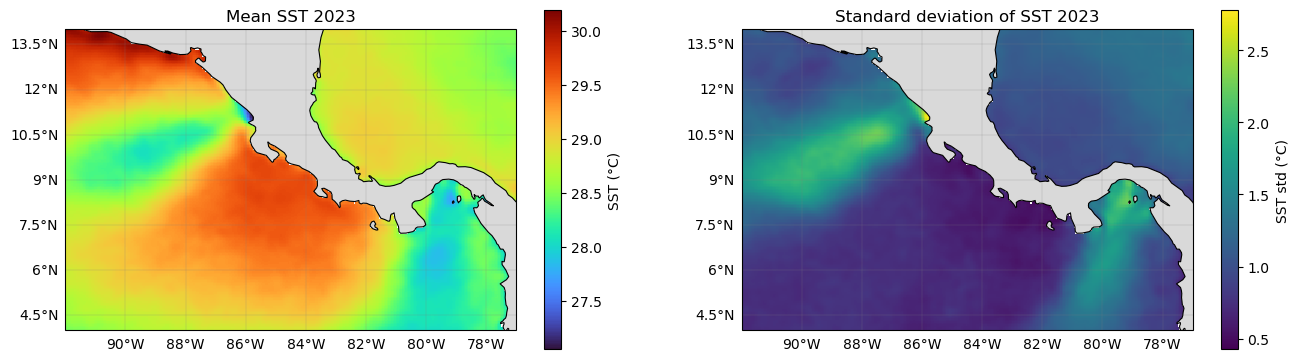

In [57]:
sst_c = to_celsius(ds_sst[VAR_SST])     # daily SST in °C, used in A.1 and A.2

### STUDENT: # TODO: the time mean and the time standard deviation of sst_c
### STUDENT: sst_mean = ...
### STUDENT: sst_std = ...
### BEGIN SOLUTION
sst_mean = sst_c.mean(dim="time")
sst_std = sst_c.std(dim="time")
### END SOLUTION

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), subplot_kw={"projection": proj})
panels = [(sst_mean, "Mean SST 2023", "turbo", "SST (°C)"),
          (sst_std, "Standard deviation of SST 2023", "viridis", "SST std (°C)")]
for ax, (field, title, cmap, label) in zip(axes, panels):    # one panel per field
    field.plot(ax=ax, transform=proj, cmap=cmap, cbar_kwargs={"label": label, "shrink": 0.8})
    ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="0.85", zorder=2)
    ax.coastlines(resolution="50m", linewidth=0.8, zorder=3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
    gl.top_labels = gl.right_labels = False
    ax.set_title(title)
plt.show()
### HINT: The mean is `sst_c.mean(dim="time")`, as in TP1a; the standard deviation works the same way with `.std(...)`.

**✅ Check**:
- **Mean**: ≈ 27–30 °C, as in TP1a.
- **Standard deviation**: from ≈ 0.4 to ≈ 2.8 °C. Largest right at the **Gulf of Papagayo** (≈ 11°N, 86°W, up to 2.8 °C) and in the **Gulf of Panama** (≈ 1.7 °C): the two upwelling areas, where winter winds bring up cold water. Smallest in the open Pacific to the south-west (≈ 0.7 °C); the Caribbean is in between (≈ 1.2 °C).

💬 The standard deviation does not change with `to_celsius()`: a difference of 1 K is a difference of 1 °C. If your **mean** colorbar goes up to ~300, though, you forgot the conversion.

## A.2 Two time series: Pacific vs Caribbean

In TP1a you plotted the SST at one point. Here we compare the two sides of Costa Rica on the same plot: the **Pacific** at the Gulf of Papagayo (87°W, 10°N), where strong trade-wind jets blow across the isthmus in winter, and the **Caribbean** (82°W, 12°N).

**🎯 Your turn**: inside the loop, select the SST time series at the grid point nearest to `(lon0, lat0)`.

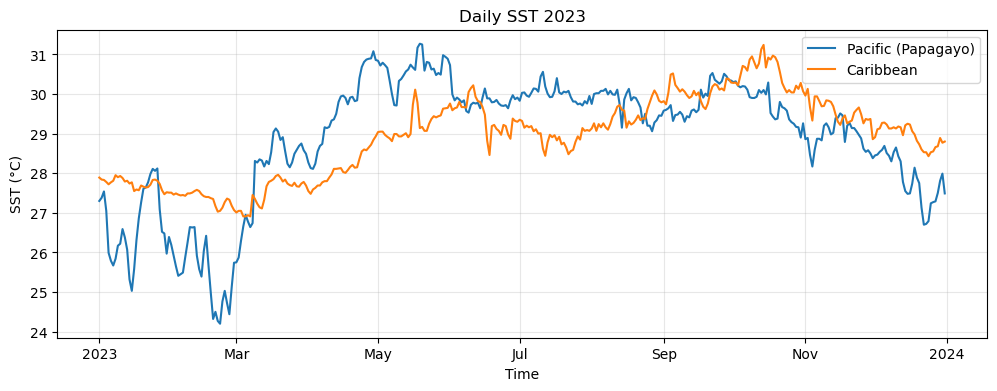

In [58]:
points = {"Pacific (Papagayo)": (-87.0, 10.0), "Caribbean": (-82.0, 12.0)}

fig, ax = plt.subplots(figsize=(12, 4))
for name, (lon0, lat0) in points.items():
### STUDENT:     # TODO: select the SST (in °C) at the grid point nearest to (lon0, lat0)
### STUDENT:     ts = ...
### BEGIN SOLUTION
    ts = sst_c.sel(longitude=lon0, latitude=lat0, method="nearest")
### END SOLUTION
    ts.plot(ax=ax, label=name)
ax.set_ylabel("SST (°C)")
ax.set_title("Daily SST 2023")
ax.legend()
ax.grid(alpha=0.3)
plt.show()
### HINT: `sst_c.sel(longitude=..., latitude=..., method="nearest")`, as in TP1a — with `lon0` and `lat0`.

**✅ Check**:
- **Pacific**: sharp cold events in January–February, down to **≈ 24 °C**, then a maximum of **≈ 31 °C in May** and a plateau near 30 °C. Monthly means go from ≈ 25.5 °C (February) to ≈ 30.6 °C (May).
- **Caribbean**: a smoother, weaker cycle, with no cold events: coldest in February–March (monthly mean ≈ 27.4 °C), warmest in **September–October** (≈ 30.5 °C).

💬 **Think**: why are the cold events only on the Pacific side? (Hint: Course 1, the Papagayo jet. The trade winds blow from the Caribbean through a gap in the mountains, and push the surface water offshore on the Pacific side only.)

## A.3 A vertical section: World Ocean Atlas climatology

`temp_seas.cdf` is a **3D climatology** (Course 1): long-term mean temperature, on a 1° grid, 33 depth levels, for **4 seasons**. Its dimension names are **not** the usual ones:

| Usual name | In this file | Values |
|---|---|---|
| longitude | `X` | −179.5 … 179.5 |
| latitude | `Y` | −89.5 … 89.5 |
| depth | `Z` | 0 … 5500 m |
| time | `T` | 4 seasons (1.5, 4.5, 7.5, 10.5 = mid-season months) |

So before plotting a single section we must **average over the 4 seasons** (`T`).

**🎯 Your turn**: build the annual-mean temperature section along 9.5°N, for the Eastern Pacific (120°W–84°W) and the upper 500 m.

<xarray.Dataset> Size: 34MB
Dimensions:      (T: 4, Z: 33, Y: 180, X: 360)
Coordinates:
  * T            (T) float32 16B 1.5 4.5 7.5 10.5
  * Z            (Z) float32 132B 0.0 10.0 20.0 30.0 ... 4.5e+03 5e+03 5.5e+03
  * Y            (Y) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * X            (X) float32 1kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Data variables:
    temperature  (T, Z, Y, X) float32 34MB ...


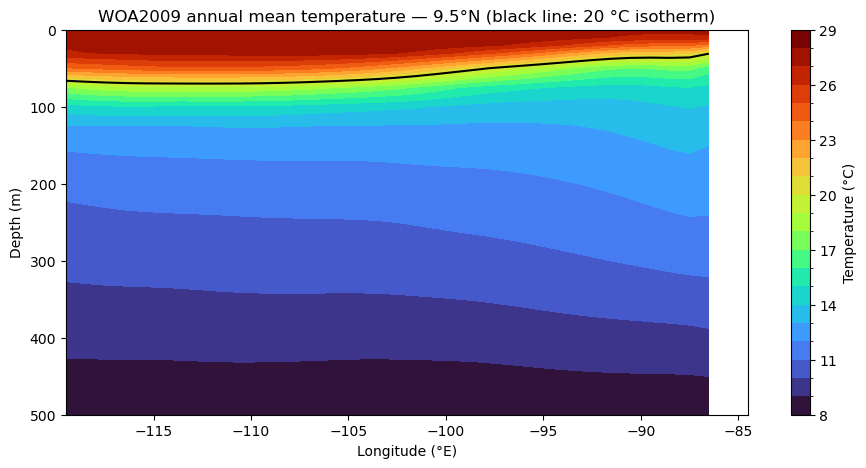

In [59]:
ds_woa = xr.open_dataset(WOA_FILE)
print(ds_woa)

lat_section = 9.5

### STUDENT: # TODO: 1) average "temperature" over the season dimension
### STUDENT: #       2) select the latitude nearest to lat_section
### STUDENT: #       3) keep X between -120 and -84 and Z between 0 and 500
### STUDENT: temp_section = ...
### BEGIN SOLUTION
temp_section = (
    ds_woa["temperature"]
    .mean(dim="T")
    .sel(Y=lat_section, method="nearest")
    .sel(X=slice(-120, -84), Z=slice(0, 500))
)
### END SOLUTION

fig, ax = plt.subplots(figsize=(11, 5))
temp_section.plot.contourf(x="X", y="Z", ax=ax, levels=np.arange(8, 30, 1), cmap="turbo",
                           cbar_kwargs={"label": "Temperature (°C)"})
temp_section.plot.contour(x="X", y="Z", ax=ax, levels=[20], colors="k", linewidths=1.5)
ax.invert_yaxis()
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Depth (m)")
ax.set_title(f"WOA2009 annual mean temperature — {lat_section}°N (black line: 20 °C isotherm)")
plt.show()
### HINT: Chain three steps: `ds_woa["temperature"].mean(dim="T")`, then `.sel(Y=lat_section, method="nearest")`, then `.sel(X=slice(...), Z=slice(...))`.
### HINT: `method="nearest"` cannot be mixed with `slice` in the same `.sel()`: that's why there are two.

**✅ Check**: a warm surface layer (> 26 °C) over a sharp **thermocline** (tight colour gradient). The 20 °C isotherm (a common marker of the thermocline) rises from **~70 m at 120°W to ~30-35 m east of 90°W**: the thermocline shoals towards the **Costa Rica Dome**, a region of open-ocean upwelling centred near 9°N, 90°W. The white strip on the right is land (Costa Rica on the 1° WOA grid).

⚠️ If you get `KeyError: 'lat'` or `'depth'`, go back to the table above: the dimensions are `X/Y/Z/T`.

### 🚀 Advanced track A — the seasonal cycle of the Costa Rica Dome

Instead of averaging over `T`, plot the **4 seasonal sections** along 9.5°N in a 2×2 figure with a single shared colorbar. In which season is the Dome shallowest? Does it match the timing of the Papagayo cold events seen in A.2?

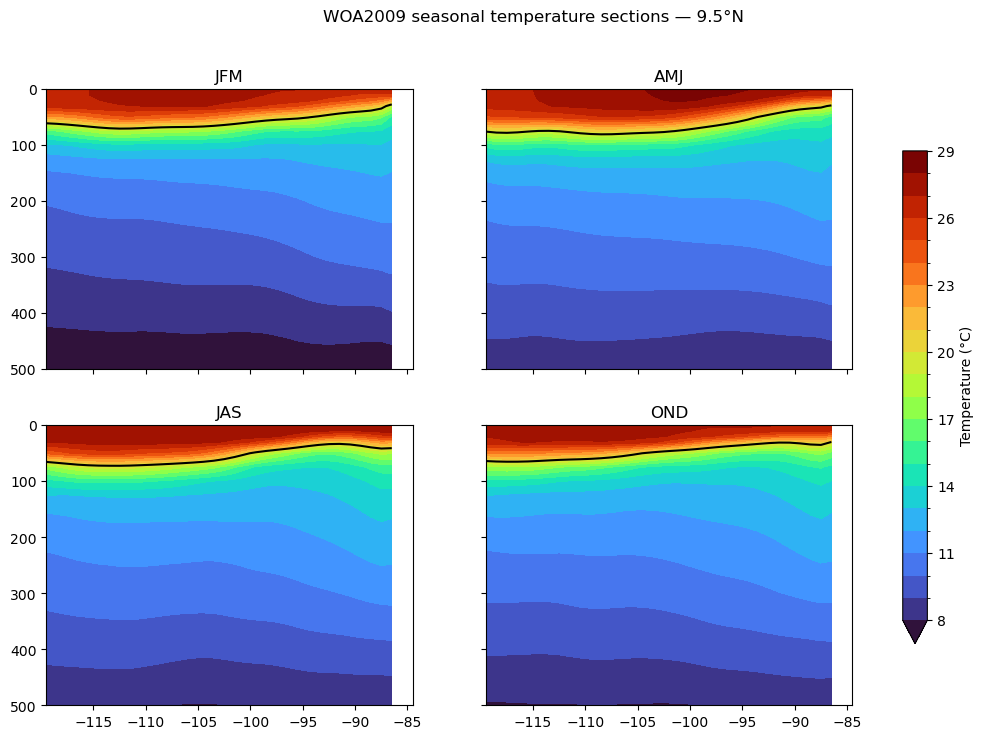

In [60]:
### STUDENT: # 🚀 Your code here (hint: loop over ds_woa.T.values and use .sel(T=...))
### BEGIN SOLUTION
season_names = {1.5: "JFM", 4.5: "AMJ", 7.5: "JAS", 10.5: "OND"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
for ax, t in zip(axes.flat, ds_woa.T.values):
    sec = (ds_woa["temperature"].sel(T=t)
           .sel(Y=lat_section, method="nearest")
           .sel(X=slice(-120, -84), Z=slice(0, 500)))
    cf = sec.plot.contourf(x="X", y="Z", ax=ax, levels=np.arange(8, 30, 1), cmap="turbo",
                           add_colorbar=False)
    sec.plot.contour(x="X", y="Z", ax=ax, levels=[20], colors="k", linewidths=1.5)
    ax.set_title(season_names[float(t)])
    ax.set_xlabel("")
    ax.set_ylabel("")
axes[0, 0].invert_yaxis()   # axes are shared: inverting one inverts all
fig.colorbar(cf, ax=axes, label="Temperature (°C)", shrink=0.8)
fig.suptitle(f"WOA2009 seasonal temperature sections — {lat_section}°N")
plt.show()

# Answer: the 20 °C isotherm forms a clear dome, ~35 m deep near 90-92°W, in JAS
# (and still in OND): the Dome is strongest in the second half of the year. In JFM the
# thermocline is shallow only right at the coast. The Papagayo cold events (A.2) peak in
# JFM: they are a *coastal* wind-driven process, distinct from the Dome, although the
# winter wind jets also help "seed" the Dome.
### END SOLUTION
### HINT: `for ax, t in zip(axes.flat, ds_woa.T.values):` then `.sel(T=t)` instead of `.mean(dim="T")`.
### HINT: `add_colorbar=False` in each panel, then a single `fig.colorbar(cf, ax=axes)`.

---
# Part B — Command line: NCO and CDO

## B.0 Why the command line?

On an HPC cluster you often handle files too large to load into memory, or hundreds of files to process in a batch script (SLURM job). **NCO** (netCDF Operators) and **CDO** (Climate Data Operators) are made for that: one command, one operation, no Python code, and very fast.

In a Jupyter cell, a line starting with `!` is sent to the shell. Python variables can be inserted with **single braces**: `!ncdump -h {SST_FILE}`.

## B.1 NCO: `ncdump`, `ncks`, `ncwa`

### 📋 NCO cheat-sheet

| Task | Command |
|---|---|
| Show the header (dimensions, variables, attributes) | `ncdump -h in.nc` |
| Print the values of one variable | `ncdump -v VAR in.nc` |
| Cut a sub-region (by **coordinate values**) | `ncks -O -d DIM,MIN,MAX -d DIM2,MIN,MAX in.nc out.nc` |
| Keep only some variables | `ncks -O -v VAR1,VAR2 in.nc out.nc` |
| Average over a dimension | `ncwa -O -a DIM in.nc out.nc` |

- `-O` = **overwrite** the output if it already exists (otherwise re-running the cell fails or asks a question).
- ⚠️ In `-d DIM,MIN,MAX`, write the bounds **with a decimal point** (`-92.0`): without it (`-92`), NCO interprets them as **indices** (grid-point numbers), not coordinate values!

In [61]:
!ncdump -h {SST_FILE}

netcdf sst_costarica_2023 {
dimensions:
	time = 365 ;
	latitude = 200 ;
	longitude = 300 ;
variables:
	short analysed_sst(time, latitude, longitude) ;
		analysed_sst:_FillValue = -32768s ;
		string analysed_sst:comment = " OSTIA foundation SST" ;
		string analysed_sst:long_name = "analysed sea surface temperature" ;
		string analysed_sst:reference = "C.J. Donlon, M. Martin,J.D. Stark, J. Roberts-Jones, E. Fiedler, W. Wimmer. The operational sea surface temperature and sea ice analysis (OSTIA) system. Remote Sensing Environ., 116 (2012), pp. 140-158 http://dx.doi.org/10.1016/j.rse.2010.10.017" ;
		string analysed_sst:source = "AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, TMI-REMSS-L2P-v04, GOES13-OSISAF-L3C-v2.0, SEVIRI-OSISAF-L3C-v2.0, SLSTRA-C3S-L3C-v2.0, ATSR<1,2>-ESACCI-L3U-v2.0, AATSR-ESACCI-L3U-v2.0, AVHRR<06,07,08,09,10,11,12,14,15,16,17,18,19>-ESACCI-L3U-v2.0, AVHRRMTA-ESACCI-L3U-v2.0, GMI-REMSS-L3U-v2.0, VIIRS-OSPO-L3U-v2.0" ;
		string analysed_sst:standard_name = "sea_surface_f

**🎯 Your turn**: cut the study box (`LON_MIN…LON_MAX`, `LAT_MIN…LAT_MAX`) out of `SST_FILE` into `data_tp1/sst_costarica.nc`, then average it over time into `data_tp1/sst_costarica_mean_nco.nc`.

In [62]:
BOX_NCO = WORK_DIR / "sst_costarica.nc"
MEAN_NCO = WORK_DIR / "sst_costarica_mean_nco.nc"

### STUDENT: # TODO: complete the dimension names and bounds (with a decimal point!)
### STUDENT: !ncks -O -d ___,{LON_MIN},{LON_MAX} -d ___,___,___ {SST_FILE} {BOX_NCO}
### BEGIN SOLUTION
!ncks -O -d longitude,{LON_MIN},{LON_MAX} -d latitude,{LAT_MIN},{LAT_MAX} {SST_FILE} {BOX_NCO}
### END SOLUTION
!ncdump -h {BOX_NCO} | head -15

### STUDENT: # TODO: complete the operator and the dimension to average over
### STUDENT: !___ -O -a ___ {BOX_NCO} {MEAN_NCO}
### BEGIN SOLUTION
!ncwa -O -a time {BOX_NCO} {MEAN_NCO}
### END SOLUTION
!ncdump -h {MEAN_NCO} | head -15
### HINT: Dimension names are in the `ncdump -h` output above: `longitude`, `latitude`.
### HINT: Average over a dimension: `ncwa -O -a DIM in.nc out.nc` (see the cheat-sheet).

netcdf sst_costarica {
dimensions:
	time = 365 ;
	latitude = 200 ;
	longitude = 240 ;
variables:
	short analysed_sst(time, latitude, longitude) ;
		analysed_sst:_FillValue = -32768s ;
		string analysed_sst:comment = " OSTIA foundation SST" ;
		string analysed_sst:long_name = "analysed sea surface temperature" ;
		string analysed_sst:reference = "C.J. Donlon, M. Martin,J.D. Stark, J. Roberts-Jones, E. Fiedler, W. Wimmer. The operational sea surface temperature and sea ice analysis (OSTIA) system. Remote Sensing Environ., 116 (2012), pp. 140-158 http://dx.doi.org/10.1016/j.rse.2010.10.017" ;
		string analysed_sst:source = "AMSR2-REMSS-L2P-v2.0, AMSRE-REMSS-L2P-v2.0, TMI-REMSS-L2P-v04, GOES13-OSISAF-L3C-v2.0, SEVIRI-OSISAF-L3C-v2.0, SLSTRA-C3S-L3C-v2.0, ATSR<1,2>-ESACCI-L3U-v2.0, AATSR-ESACCI-L3U-v2.0, AVHRR<06,07,08,09,10,11,12,14,15,16,17,18,19>-ESACCI-L3U-v2.0, AVHRRMTA-ESACCI-L3U-v2.0, GMI-REMSS-L3U-v2.0, VIIRS-OSPO-L3U-v2.0" ;
		string analysed_sst:standard_name = "sea_surface_founda

**✅ Check**:
- `sst_costarica.nc`: `time = 365`, `latitude = 200`, `longitude = 240` (10° / 0.05° = 200 and 12° / 0.05° = 240).
- `sst_costarica_mean_nco.nc`: **no `time` dimension any more** (it has been averaged out), still 200 × 240.

Since `LON_MIN` etc. are Python floats (`-92.0`), `{LON_MIN}` is written with a decimal point — good. If you get *"dimension … not in input file"*, check the exact names in the `ncdump -h` output.

💡 Why `ncwa` and not `ncra`? `ncra` (*record average*) only averages over the **record** (unlimited) dimension, and `time` is not one in this file. `ncwa -a DIM` averages over **any** dimension.

## B.2 CDO: `sinfo`, `sellonlatbox`, `timmean`

### 📋 CDO cheat-sheet

| Task | Command |
|---|---|
| Short summary of a file | `cdo sinfo in.nc` |
| Cut a lon/lat box | `cdo -O sellonlatbox,LON1,LON2,LAT1,LAT2 in.nc out.nc` |
| Time mean (whole period) | `cdo -O timmean in.nc out.nc` |
| Monthly means | `cdo -O monmean in.nc out.nc` |
| Spatial (area-weighted) mean | `cdo -O fldmean in.nc out.nc` |
| **Chaining** (right to left, no intermediate file) | `cdo -O timmean -sellonlatbox,LON1,LON2,LAT1,LAT2 in.nc out.nc` |

Note the order of arguments: CDO takes **lon, lon, lat, lat**, without dimension names.

In [63]:
!cdo sinfo {SST_FILE}

cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lon<
cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lat<
   File format : NetCDF4
    -1 : Institut Source   T Steptype Levels Num    Points Num Dtype : Parameter ID
     1 : unknown  AMSR2-REMSS-L2P-v2 v instant       1   1     60000   1  I16  : -1            
   Grid coordinates :
     1 : lonlat                   : points=60000 (300x200)
                        longitude : -91.975 to -77.025 by 0.04999999 degrees_east
                         latitude : 4.025 to 13.975 by 0.05 degrees_north
   Vertical coordinates :
     1 : surface                  : levels=1
   Time coordinate :
                             time : 365 steps
     RefTime =  1981-01-01 00:00:00  Units = seconds  Calendar = proleptic_gregorian
  YYYY-MM-DD hh:mm:ss  YYYY-MM-DD hh:mm:ss  YYYY-MM-DD hh:mm:ss  YYYY-MM-DD hh:mm:ss
  2023-01-01 00:00:00  2023-01-02 00:00:00  2023-01-03 00:00:00  2023-01-04 00:00:00
  2023-01-05 00:00:

**🎯 Your turn**: do the same as in B.1 with CDO: cut the box into `data_tp1/sst_costarica_cdo.nc`, then compute the time mean into `data_tp1/sst_costarica_mean_cdo.nc`.

In [64]:
BOX_CDO = WORK_DIR / "sst_costarica_cdo.nc"
MEAN_CDO = WORK_DIR / "sst_costarica_mean_cdo.nc"

### STUDENT: # TODO: complete the operator arguments
### STUDENT: !cdo -O sellonlatbox,___,___,___,___ {SST_FILE} {BOX_CDO}
### BEGIN SOLUTION
!cdo -O sellonlatbox,{LON_MIN},{LON_MAX},{LAT_MIN},{LAT_MAX} {SST_FILE} {BOX_CDO}
### END SOLUTION

### STUDENT: # TODO: complete the operator
### STUDENT: !cdo -O ___ {BOX_CDO} {MEAN_CDO}
### BEGIN SOLUTION
!cdo -O timmean {BOX_CDO} {MEAN_CDO}
### END SOLUTION
!cdo sinfo {MEAN_CDO}
### HINT: CDO order is lon, lon, lat, lat: `{LON_MIN},{LON_MAX},{LAT_MIN},{LAT_MAX}`.
### HINT: Time mean over the whole period: see the cheat-sheet.

cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lon<
cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lat<
cdo    sellonlatbox: Processed 21900000 values from 1 variable over 365 timesteps [0.16s 71MB]
cdo    timmean:                        1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 7 7 7 7 7 7 7 7 7 7 8 8 8 8 8 8 8 8 8 8 9 9 9 9 9 9 9 9 9 910cdo    timmean: Processed 17520000 values from 1 variable over 365 timesteps [0.06s 40MB]
   File format : NetCDF4
    -1 : Institut Source   T Steptype Levels Num    Points Num Dtype : Parameter ID
     1 : unknown  AMSR2-REMSS-L2P-v2 v instant       1   1     48000   1  F32  : -1            
   Grid coordinates :
     1 : lonlat                   : points=48000 (240x200)
                        longitude : -91.975 to -80.025 by 0.04999999 degrees_east
                         latitude : 4.025 to 13.975 by 0.05 degrees_north
   Vert

**✅ Check**: `cdo sinfo` on the result shows a grid of **240 × 200** points (`points=48000 (240x200)`), and **1 time step** (dated 2023-07-02, the middle of the period).

CDO prints `cdi warning … Variable not found - >lon<` (and, when chaining, sometimes a long `HDF5-DIAG` message): the file's metadata mentions `lon lat` while the coordinates are called `longitude latitude`. These are **warnings, not errors** — what matters is that the output file is created and correct.

### 🚀 Advanced track B — chaining CDO operators, and a subtle difference

1. In **one** CDO command (chaining, no intermediate file), compute the **monthly mean SST averaged over the study box**, from `SST_FILE` into `data_tp1/sst_box_monthly_cdo.nc` (hint: `fldmean`, `monmean`, `sellonlatbox`).
2. Compute the same 12 values in Python with xarray (hint: `.resample(time="1MS").mean()` then `.mean(["latitude", "longitude"])`) and compare them.
3. The two series differ slightly. Why? Read the CDO documentation of `fldmean`, then fix your xarray calculation so they agree (hint: `.weighted(...)`).

In [65]:
### STUDENT: # 🚀 Your code here
### BEGIN SOLUTION
MONTHLY_CDO = WORK_DIR / "sst_box_monthly_cdo.nc"
!cdo -O fldmean -monmean -sellonlatbox,{LON_MIN},{LON_MAX},{LAT_MIN},{LAT_MAX} {SST_FILE} {MONTHLY_CDO}

cdo_series = to_celsius(xr.open_dataset(MONTHLY_CDO)[VAR_SST]).squeeze()

box = to_celsius(ds_sst[VAR_SST]).sel(longitude=slice(LON_MIN, LON_MAX),
                                      latitude=slice(LAT_MIN, LAT_MAX))
box_monthly = box.resample(time="1MS").mean()
xr_plain = box_monthly.mean(["latitude", "longitude"])

# fldmean weights each grid cell by its area, i.e. by cos(latitude)
weights = np.cos(np.deg2rad(box.latitude))
xr_weighted = box_monthly.weighted(weights).mean(["latitude", "longitude"])

print("month   CDO fldmean   xarray plain   xarray weighted")
for m in range(12):
    print(f"{m + 1:5d}   {float(cdo_series[m]):11.3f}   {float(xr_plain[m]):12.3f}   {float(xr_weighted[m]):15.3f}")

# Answer: CDO fldmean is area-weighted (cells get smaller towards the poles, ~cos(lat)),
# a plain xarray .mean() gives every grid point the same weight. The difference is tiny
# here (a few thousandths of °C over 4-14°N) but grows for big or high-latitude boxes.
# With the cos(lat) weights, xarray and CDO agree to 0.001 °C.
### END SOLUTION
### HINT: CDO chain, read right to left: `fldmean -monmean -sellonlatbox,...`.
### HINT: Area weights on a lon/lat grid: `np.cos(np.deg2rad(box.latitude))`.

cdo(1) monmean: Process started
cdo(2) sellonlatbox: Process started
cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lon<
cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lat<
cdo    fldmean:   10cdo    fldmean: Processed 576000 values from 1 variable over 12 timesteps [0.09s 43MB]
month   CDO fldmean   xarray plain   xarray weighted
    1        27.562         27.561            27.562
    2        27.723         27.719            27.723
    3        28.499         28.495            28.499
    4        29.207         29.202            29.207
    5        29.940         29.939            29.940
    6        29.599         29.601            29.599
    7        29.376         29.377            29.376
    8        29.458         29.460            29.458
    9        29.568         29.572            29.568
   10        29.385         29.390            29.385
   11        28.874         28.877            28.874
   12        28.815         28.815        

### 🚀 Advanced track C — process several files with a `%%bash` loop

On a cluster you often run the same command on many files (one per year, per month…). This is where a **`%%bash` cell** is handy: when `%%bash` is the **first line**, the whole cell is a shell script, exactly what you would put in a batch (SLURM) script. Two rules:
- a `%%bash` cell **cannot see Python variables**: the Python cell below exports the ones we need with `os.environ`;
- inside the `%%bash` cell, write them with a dollar sign: `$OBS_DIR`, `$BOX`… (not `{OBS_DIR}`).

**Task**: with a `for` loop, compute the **2023 and 2024 mean SST over the study box**, from `COSTARICA_DS/sst_costarica_2023.nc` and `sst_costarica_2024.nc`, into `data_tp1/sst_box_mean_2023.nc` and `data_tp1/sst_box_mean_2024.nc` (one CDO command per year: `fldmean -timmean -sellonlatbox,...`). Then print the two values in Python. Which year was warmer?

📋 Bash loop syntax:
```bash
for year in 2023 2024; do
    echo "Processing $year"
    some_command input_${year}.nc output_${year}.nc
done
```
`${year}` (with braces) separates the variable name from the text around it.

In [66]:
import os

# Export the Python variables needed by the %%bash cell below
os.environ["OBS_DIR"] = str(OBS_DIR)
os.environ["WORK_DIR"] = str(WORK_DIR)
os.environ["BOX"] = f"{LON_MIN},{LON_MAX},{LAT_MIN},{LAT_MAX}"
print(os.environ["BOX"])

-92.0,-80.0,4.0,14.0


In [67]:
%%bash
### STUDENT: # 🚀 Your code here: a for loop over 2023 and 2024
### BEGIN SOLUTION
for year in 2023 2024; do
    echo "Processing $year"
    cdo -O fldmean -timmean -sellonlatbox,$BOX $OBS_DIR/COSTARICA_DS/sst_costarica_${year}.nc $WORK_DIR/sst_box_mean_${year}.nc
done
ls -lh $WORK_DIR/sst_box_mean_*.nc
### END SOLUTION
### HINT: Inside the loop: `cdo -O fldmean -timmean -sellonlatbox,$BOX INPUT OUTPUT`, with `${year}` in both file names.
### HINT: Input: `$OBS_DIR/COSTARICA_DS/sst_costarica_${year}.nc` · output: `$WORK_DIR/sst_box_mean_${year}.nc`.

Processing 2023


cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lon<
cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lat<
HDF5-DIAG: Error detected in HDF5 (2.1.0) thread 2:
  #000: /Users/runner/miniforge3/conda-bld/hdf5_1780923097427/work/src/H5F.c line 490 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: /Users/runner/miniforge3/conda-bld/hdf5_1780923097427/work/src/H5VLcallback.c line 4109 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: /Users/runner/miniforge3/conda-bld/hdf5_1780923097427/work/src/H5VLcallback.c line 4045 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: /Users/runner/miniforge3/conda-bld/hdf5_1780923097427/work/src/H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major:

Processing 2024


cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lon<
cdi  warning (read_coordinates_vars): NetCDF: Variable not found - >lat<
HDF5-DIAG: Error detected in HDF5 (2.1.0) thread 2:
  #000: /Users/runner/miniforge3/conda-bld/hdf5_1780923097427/work/src/H5F.c line 490 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: /Users/runner/miniforge3/conda-bld/hdf5_1780923097427/work/src/H5VLcallback.c line 4109 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: /Users/runner/miniforge3/conda-bld/hdf5_1780923097427/work/src/H5VLcallback.c line 4045 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: /Users/runner/miniforge3/conda-bld/hdf5_1780923097427/work/src/H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major:

-rw-r--r--@ 1 gcambon  staff    37K Oct  7 15:07 data_tp1/sst_box_mean_2023.nc
-rw-r--r--@ 1 gcambon  staff    37K Oct  7 15:07 data_tp1/sst_box_mean_2024.nc


In [68]:
### STUDENT: # 🚀 Then read the two files and print the two values in °C
### BEGIN SOLUTION
for year in (2023, 2024):
    val = to_celsius(xr.open_dataset(WORK_DIR / f"sst_box_mean_{year}.nc")[VAR_SST]).squeeze()
    print(f"{year}: {float(val):.2f} °C")
### END SOLUTION
### HINT: `to_celsius(xr.open_dataset(WORK_DIR / f"sst_box_mean_{year}.nc")[VAR_SST]).squeeze()` in a Python `for` loop.

2023: 29.01 °C
2024: 28.70 °C


**✅ Check**: the loop prints `Processing 2023` then `Processing 2024`, and creates two small files (≈ 37 kB each). Mean SST over the box: **≈ 29.01 °C in 2023** and **≈ 28.70 °C in 2024**: 2023 was warmer (El Niño 2023–24; by mid-2024 the region was cooling down).

You will also see `cdi warning … Variable not found - >lon<` (and `>lat<`): harmless. The file's `analysed_sst:coordinates` attribute says `"lon lat"`, but the variables are called `longitude` and `latitude` — a real example of **wrong metadata** (Course 2). CDO falls back on the right coordinates.

To process 10 years instead of 2, only the first line changes: `for year in $(seq 2015 2024); do`.

---
## 2. Cross-check: three methods, one number

A good habit in science: **never trust a single calculation**. You have computed the 2023 mean SST over the box in three independent ways (xarray, NCO, CDO). Do they agree?

**🎯 Your turn**: compute the xarray value (box selection + mean over everything), and read the NCO and CDO results.

In [69]:
# NCO and CDO: open the output files and average the remaining 2D map
val_nco = float(to_celsius(xr.open_dataset(MEAN_NCO)[VAR_SST]).mean())
val_cdo = float(to_celsius(xr.open_dataset(MEAN_CDO)[VAR_SST]).mean())

### STUDENT: # TODO: select the box in ds_sst (latitude is increasing, see section 1), convert to °C, average
### STUDENT: val_xr = ...
### BEGIN SOLUTION
sst_box = ds_sst[VAR_SST].sel(longitude=slice(LON_MIN, LON_MAX),
                              latitude=slice(LAT_MIN, LAT_MAX))
val_xr = float(to_celsius(sst_box).mean())
### END SOLUTION

for name, v in [("Python/xarray", val_xr), ("NCO", val_nco), ("CDO", val_cdo)]:
    print(f"{name:15s} : {v:.3f} °C")
### HINT: Same box as NCO/CDO: `ds_sst[VAR_SST].sel(longitude=slice(LON_MIN, LON_MAX), latitude=slice(LAT_MIN, LAT_MAX))`.
### HINT: Then `to_celsius(...)`, `.mean()`, and `float(...)` to get a plain number.

Python/xarray   : 29.008 °C
NCO             : 29.008 °C
CDO             : 29.008 °C


**✅ Check**: the three values agree to within **~0.001 °C**, around **29.01 °C**.

💬 If one of them is `nan`, or clearly different: which selection is wrong? Check the box bounds, the latitude order, the units. Finding *why* two methods disagree is often where you learn the most.

---
## 3. 🐞 Debugging exercise

A colleague sends you this cell: *"it should print the 2023 mean SST over the study box, but it doesn't work"*. It contains **three bugs**. Two raise an error, one is **silent** (no error, but a wrong result).

Run it, **read the error message** (the last line is usually the most useful), fix one bug, run again… until it prints the same value as `val_xr` in section 2.

In [70]:
### STUDENT: # 🐞 Fix me! (3 bugs)
### STUDENT: sst_box_bug = ds_sst["sea_surface_temperature"].sel(lon=slice(-92, -80), latitude=slice(14, 4))
### BEGIN SOLUTION
# Fixed version
sst_box_bug = ds_sst["analysed_sst"].sel(longitude=slice(-92, -80), latitude=slice(4, 14))
### END SOLUTION
sst_box_bug = to_celsius(sst_box_bug)
print(f"Box mean SST: {float(sst_box_bug.mean()):.3f} °C")
### BEGIN SOLUTION

# Bug 1: KeyError 'sea_surface_temperature'  -> the variable is called analysed_sst
#        (check with list(ds_sst.data_vars)).
# Bug 2: KeyError / ValueError on 'lon'        -> the dimension is called longitude.
# Bug 3 (silent): latitude is stored increasing, so slice(15, 5) selects nothing;
#        the mean of an empty array is nan (with only a RuntimeWarning).
### END SOLUTION
### HINT: Read the **last line** of each error message.
### HINT: Check `list(ds_sst.data_vars)`, `ds_sst.dims`, and the order of the latitudes (section 1).

Box mean SST: 29.008 °C


**✅ Check**: the fixed cell prints the same value as `val_xr` (≈ 29.01 °C). If you get `nan` without any error, you have not found the silent bug yet: look at the order of the latitudes (section 1).

---
## 4. NCO/CDO vs Python: when to use what?

| Criterion | NCO / CDO | Python (xarray) |
|---|---|---|
| Batch processing of many files, SLURM scripts | ✅ Very well suited | Possible, more verbose |
| Large files (avoid loading everything into memory) | ✅ Optimised | Needs dask to stay efficient |
| Maps and figures | ❌ Not designed for this | ✅ Very rich (matplotlib, cartopy) |
| Advanced statistics, machine learning | ❌ | ✅ |
| Learning curve | Quick for simple operations | Longer at first |
| Reproducibility / sharing | A script of commands | ✅ Self-documenting notebook |

**In practice**: many people use CDO/NCO for the upstream pre-processing (extraction, averaging, regridding), then Python for the detailed analysis and the figures.

---
## 5. In pairs: apply it to another variable

Pick **one** of these files (in `OBS_DIR`), and with your partner:

| File | What |
|---|---|
| `COSTARICA_DS/ssh_costarica_2023.nc` | Sea surface height (satellite altimetry), daily 2023 |
| `COSTARICA_DS/sst_costarica_2024.nc` | Same SST as today, for 2024 (El Niño year!) |
| `GLOBAL_DS/WOA2009/salt_seas.cdf` | Salinity climatology (same structure as `temp_seas.cdf`) |
| `GLOBAL_DS/WOA2009/o2_seas.cdf` | Dissolved oxygen climatology |

1. Find the variable name, dimensions and units (`ncdump -h`).
2. Make **one map** and **one time series or section** with a sensible colorbar and units.
3. Compute **one mean value by two different methods** (e.g. xarray and CDO) and check that they agree.
4. Write 2-3 sentences: what do you see, and what physical process could explain it?

In [71]:
# Your code here

<!-- SOLUTION ONLY -->
### 👩‍🏫 Instructor notes

There is no single correct output. When circulating, check that each pair has:
- a map with a sensible colorbar range and units (SSH in m, O2 in ml/l or µmol/kg depending on the file);
- a time series / section with a plausible pattern (not flat, no absurd units);
- two independent means that agree — if they don't, use it as a debugging opportunity rather than fixing it for them.

Good discussion points: SST 2024 vs 2023 (El Niño 2023-24 warming, then decay); the oxygen minimum zone of the Eastern Tropical Pacific (very low O2 from ~100 m); the SSH low over the Costa Rica Dome.

---
## To go further

- xarray documentation: <https://docs.xarray.dev>
- NCO documentation: <https://nco.sourceforge.net/nco.html>
- CDO documentation and reference card: <https://code.mpimet.mpg.de/projects/cdo>
- Next TP (TP2a): instead of using files already on Kabre, you will **download your own data** from Copernicus Marine.